# Phase B Archetype Re-clustering — 2026-04-30

Three tracks: Gower+hierarchical, mixed-type GMM, supervised mood classifier. Decision rules in spec.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from IPython.display import display
import gower
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

DATA = Path('../../../data/extracted.json')
MOODS = Path('mood_labels.csv')
FIGS = Path('../figures/2026-04-30-phase-b')
FIGS.mkdir(parents=True, exist_ok=True)

CONT_VARS = ['btn_radius','card_radius','heading_weight','body_line_height',
             'heading_letter_spacing','brand_l','brand_c','brand_h','gray_chroma','accent_offset']
ORD_VARS  = ['shadow_intensity','btn_shape']
BOOL_VARS = ['is_fully_pill','dark_mode_present']
ALL_VARS  = CONT_VARS + ORD_VARS + BOOL_VARS

In [2]:
df = pd.DataFrame(json.loads(DATA.read_text()))
moods = pd.read_csv(MOODS)
df = df.merge(moods, on='system', how='left')
print(f'rows: {len(df)}; mood-labeled: {df["mood"].notna().sum()}')
print('\nFailure rate per variable:')
for v in ALL_VARS:
    null = df[v].isna().sum()
    print(f'  {v:24s} {null}/{len(df)} ({null/len(df)*100:.1f}%)')
print('\nMood distribution:')
print(df['mood'].value_counts().to_string())
print('\nis_fully_pill distribution:')
print(df['is_fully_pill'].value_counts(dropna=False).to_string())

rows: 58; mood-labeled: 58

Failure rate per variable:
  btn_radius               2/58 (3.4%)
  card_radius              20/58 (34.5%)
  heading_weight           1/58 (1.7%)
  body_line_height         2/58 (3.4%)
  heading_letter_spacing   7/58 (12.1%)
  brand_l                  1/58 (1.7%)
  brand_c                  1/58 (1.7%)
  brand_h                  1/58 (1.7%)
  gray_chroma              10/58 (17.2%)
  accent_offset            20/58 (34.5%)
  shadow_intensity         17/58 (29.3%)
  btn_shape                1/58 (1.7%)
  is_fully_pill            1/58 (1.7%)
  dark_mode_present        1/58 (1.7%)

Mood distribution:
mood
bold_energetic      17
clean_minimal       13
professional        12
playful_creative     9
warm_friendly        7

is_fully_pill distribution:
is_fully_pill
False    56
True      1
None      1


In [3]:
# Gower distance: impute NaN per column (median for continuous, mode for categorical+bool)
mixed = df[CONT_VARS + ORD_VARS + BOOL_VARS].copy()
for v in CONT_VARS:
    mixed[v] = mixed[v].astype(float).fillna(mixed[v].median())
for v in ORD_VARS:
    mixed[v] = mixed[v].astype(float).fillna(mixed[v].mode().iloc[0])
for v in BOOL_VARS:
    mixed[v] = mixed[v].astype(float).fillna(mixed[v].mode().iloc[0])
cat_mask = np.array([False]*len(CONT_VARS) + [True]*len(ORD_VARS) + [True]*len(BOOL_VARS))
gower_dist = gower.gower_matrix(mixed.to_numpy(dtype=float), cat_features=cat_mask)
print(f'Gower distance matrix: {gower_dist.shape}, NaN entries: {np.isnan(gower_dist).sum()}')

Gower distance matrix: (58, 58), NaN entries: 0


k=3 silhouette=0.132
k=4 silhouette=0.117
k=5 silhouette=0.164
k=6 silhouette=0.128
k=7 silhouette=0.123

Gower+hierarchical best: k=5, silhouette=0.164


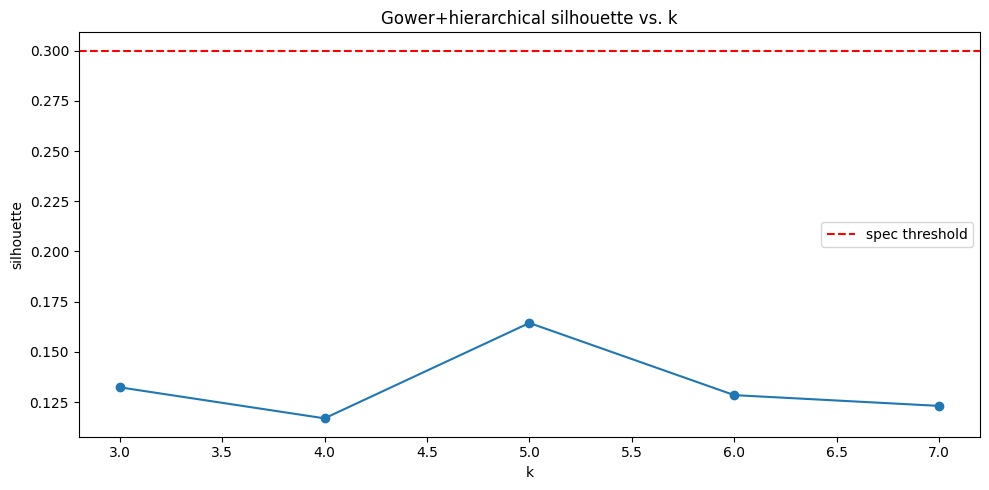

In [4]:
condensed = squareform(gower_dist, checks=False)
Z = linkage(condensed, method='average')
ks = list(range(3, 8)); sils = []
for k in ks:
    labels = fcluster(Z, t=k, criterion='maxclust')
    s = silhouette_score(gower_dist, labels, metric='precomputed')
    sils.append(s); print(f'k={k} silhouette={s:.3f}')
gower_best_k = ks[int(np.argmax(sils))]
gower_best_sil = max(sils)
print(f'\nGower+hierarchical best: k={gower_best_k}, silhouette={gower_best_sil:.3f}')
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ks, sils, 'o-')
ax.axhline(0.30, color='red', linestyle='--', label='spec threshold')
ax.set_xlabel('k'); ax.set_ylabel('silhouette'); ax.legend()
ax.set_title('Gower+hierarchical silhouette vs. k')
fig.tight_layout(); fig.savefig(FIGS / 'gower-silhouette.png', dpi=120); plt.show()

In [5]:
gower_labels = fcluster(Z, t=gower_best_k, criterion='maxclust')
df_g = df.copy(); df_g['gower_cluster'] = gower_labels
profile = df_g.groupby('gower_cluster')[CONT_VARS + ORD_VARS].mean(numeric_only=True).round(2)
display(profile)
for cid, group in df_g.groupby('gower_cluster'):
    members = ', '.join(group['system'].head(8).tolist())
    suffix = '...' if len(group) > 8 else ''
    print(f'cluster {cid} (n={len(group)}): {members}{suffix}')

,btn_radius,card_radius,heading_weight,body_line_height,heading_letter_spacing,brand_l,brand_c,brand_h,gray_chroma,accent_offset,shadow_intensity,btn_shape
gower_cluster,,,,,,,,,,,,
1,9.85,6.80,445.85,1.43,-0.87,0.54,0.18,176.26,0.02,29.07,1.82,2.08
2,16.76,2.10,520.38,1.45,-0.89,0.43,0.11,129.97,0.01,194.89,2.00,1.92
3,28.50,2.75,675.00,1.40,-0.53,0.29,0.05,236.26,0.01,322.80,4.00,2.25
4,11.23,3.46,390.46,1.39,-1.89,0.23,0.00,23.16,0.00,156.18,2.69,2.77
5,0.00,40.00,700.00,1.40,NaN,0.89,0.19,104.31,0.00,0.30,4.00,0.00


cluster 1 (n=13): cursor, kraken, lamborghini, minimax, miro, mistral.ai, nvidia, pinterest...
cluster 2 (n=27): airbnb, airtable, apple, bmw, cal, claude, clay, clickhouse...
cluster 3 (n=4): notion, posthog, raycast, sentry
cluster 4 (n=13): figma, framer, intercom, lovable, mintlify, ollama, replicate, resend...
cluster 5 (n=1): renault
